In [89]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

In [90]:
sys.path.append(os.path.dirname(os.getcwd()))
from utils import *

In [91]:
OUTPUTS_DIR = Path("/Users/hyeon/SeSAC_Project/Coach/run/test7_1/outputs")
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

In [92]:
pose_data

{'frames': [{'image_path': 'run/test7_1/inputs/00000059.png',
   'people': [{'track_id': 0,
     'bbox': [1046.6295166015625,
      170.06439208984375,
      1260.546875,
      630.19775390625],
     'bbox_score': 1.0,
     'keypoints': [[1069.7096625434028, 219.64256834983826],
      [1078.6966417100693, 212.15341877937317],
      [1070.4585774739583, 210.65558886528015],
      [1106.406494140625, 219.64256834983826],
      [1114.644558376736, 214.4001636505127],
      [1122.8826226128472, 258.5861461162567],
      [1093.6749403211807, 269.81987047195435],
      [1165.570773654514, 316.2525978088379],
      [1108.6532389322917, 341.7157063484192],
      [1118.389133029514, 369.42555975914],
      [1077.1988118489583, 375.4168794155121],
      [1131.869601779514, 403.1267328262329],
      [1093.6749403211807, 405.37347769737244],
      [1135.6141764322917, 513.2172315120697],
      [1086.9347059461807, 509.47265672683716],
      [1229.228542751736, 533.4379353523254],
      [1114.64455

In [93]:
pose_data["frames"].__len__()

32

In [94]:
Halpe_26_keypoints = {
    0: "nose",
    1: "left_eye",
    2: "right_eye",
    3: "left_ear",
    4: "right_ear",
    5: "left_shoulder",
    6: "right_shoulder",
    7: "left_elbow",
    8: "right_elbow",
    9: "left_wrist",
    10: "right_wrist",
    11: "left_hip",
    12: "right_hip",
    13: "left_knee",
    14: "right_knee",
    15: "left_ankle",
    16: "right_ankle",
    17: "head",
    18: "neck",
    19: "hip_center",
    20: "left_big_toe",
    21: "right_big_toe",
    22: "left_small_toe",
    23: "right_small_toe",
    24: "left_heel",
    25: "right_heel",
}

In [95]:
def hpe2pd(pose_data: dict) -> pd.DataFrame:
    """
    hpe json 데이터를 pandas DataFrame으로 변경
    Returns:
        pd.DataFrame has bbox(4), keypoints(26)
    """
    rows = []
    
    for frame in pose_data["frames"]:
        row = {}

        if frame['people'] == []:
            # 사람이 포착되지 않음.
            continue
        bbox = frame['people'][0]["bbox"]
        row["bbox_left"], row["bbox_up"], row["bbox_right"], row["bbox_down"] = bbox

        for i, xy in enumerate(frame['people'][0]['keypoints']):
            row[f"{Halpe_26_keypoints[i]}_x"] = xy[0]
            row[f"{Halpe_26_keypoints[i]}_y"] = xy[1]
        rows.append(row)
    
    return pd.DataFrame.from_records(rows)

In [96]:
df = hpe2pd(pose_data)
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1046.629517,170.064392,1260.546875,630.197754,1069.709663,219.642568,1078.696642,212.153419,1070.458577,210.655589,...,1076.449897,618.814240,1247.202501,578.372833,1077.947727,616.567496,1245.704671,522.953126,1140.107666,612.822921
1,1029.660889,180.629883,1219.755859,633.277344,1043.667976,222.770890,1052.508746,215.403581,1044.404707,214.666850,...,1079.031059,618.395380,1205.012041,581.558835,1082.714713,616.185187,1204.275311,528.514211,1135.759337,614.711725
2,961.070496,179.331512,1153.365601,634.242188,1006.869831,217.240743,1015.014390,208.355769,1006.129416,208.355769,...,1081.651697,619.285838,1112.749106,600.035060,1084.613355,616.324180,1139.404029,552.648530,1137.923200,610.400864
3,951.601257,170.442886,1150.759033,635.608459,980.769373,206.935359,989.854638,199.364305,980.012268,197.850094,...,1076.921759,622.586240,1070.864916,612.743869,1082.978603,616.529397,1086.764130,583.973863,1129.162032,598.358866
4,930.450317,155.854858,1125.763428,631.148315,943.785666,195.462646,953.068741,187.726750,943.012076,186.953161,...,1079.937438,621.710522,966.219765,615.521805,1078.390258,616.295395,1013.408731,597.729244,1111.654612,574.521556
5,887.126282,147.926941,1108.082397,629.719604,918.403426,190.428828,927.029271,182.587150,917.619258,181.018815,...,1073.668643,614.663589,913.698419,616.231925,1075.236979,609.174415,959.180150,609.174415,1090.920334,555.066839
6,832.787415,141.903595,1074.503662,626.407776,881.096051,190.164762,888.981861,182.278951,880.307470,179.913208,...,1051.429558,597.861166,840.878417,602.592652,1050.640977,591.552518,890.559024,606.535558,1059.315369,534.774682
7,795.743774,144.564301,1052.130249,622.334961,855.506321,192.154755,864.060158,185.156162,855.506321,182.823297,...,1031.248776,586.408859,808.071411,596.517939,1027.360669,580.965509,858.616807,608.959883,1033.581641,518.755788
8,770.720825,155.846222,921.823181,628.915222,815.473209,202.968347,823.172900,195.268656,816.243178,192.958749,...,987.946286,575.633375,785.444414,611.821921,986.406347,569.473622,837.032344,616.441736,983.326471,500.946376
9,759.675415,163.036316,891.726440,632.568909,789.018692,213.627220,797.425038,205.220875,790.547119,204.456662,...,950.267687,576.628511,779.848133,616.367600,951.031900,568.986379,827.229354,613.310747,942.625554,500.207187


### 결측치 검사

In [97]:
df.isna().sum().sum()

np.int64(0)

In [98]:
df.describe()

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,...,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,530.087206,170.326746,731.615102,628.656792,572.894888,211.524102,580.781868,204.299655,574.366037,202.687838,...,654.315438,595.520741,626.792107,601.620989,656.643627,590.232706,658.579113,579.534309,680.498784,559.763824
std,316.620345,14.728238,316.446222,5.827058,305.605231,12.445384,306.371920,12.474279,304.612171,12.672032,...,309.772091,18.817871,342.142791,17.254719,308.733983,19.622288,333.992958,38.207818,315.404216,41.475766
min,20.227394,141.903595,183.687790,610.864502,69.979104,190.164762,75.793375,182.278951,72.159455,179.913208,...,141.930711,566.066141,115.946549,565.446614,141.930711,559.252768,161.553877,505.346087,160.827093,499.446493
25%,277.024048,159.437981,490.011620,626.307129,322.422323,202.995218,329.942619,196.002952,324.115373,194.021162,...,439.593245,580.296095,315.028038,590.783874,444.683815,577.215242,362.220846,547.443724,471.899026,523.298910
50%,511.868866,169.192108,771.237823,629.756897,575.495201,212.399440,583.319446,204.988132,578.099476,204.096570,...,519.314010,588.430412,747.972888,604.414199,523.811110,581.693874,755.108524,599.828483,568.943694,564.307554
75%,776.976562,181.246956,954.399948,632.720810,825.481487,221.965471,833.394714,215.442722,826.058964,213.675953,...,998.771908,616.415245,791.101164,616.433729,996.644928,611.528327,842.428459,611.367568,995.890263,600.028196
max,1046.629517,199.154755,1260.546875,635.608459,1069.709663,229.316957,1078.696642,222.334970,1070.458577,222.334970,...,1081.651697,622.586240,1247.202501,620.518110,1084.613355,616.567496,1245.704671,616.787918,1140.107666,614.711725


In [99]:
left_ankle_x = df["left_ankle_x"]
type(left_ankle_x)

pandas.Series

In [100]:
details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    details_data = json.load(file)

In [101]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1046.629517,170.064392,1260.546875,630.197754,1069.709663,219.642568,1078.696642,212.153419,1070.458577,210.655589,...,1076.449897,618.814240,1247.202501,578.372833,1077.947727,616.567496,1245.704671,522.953126,1140.107666,612.822921
1,1029.660889,180.629883,1219.755859,633.277344,1043.667976,222.770890,1052.508746,215.403581,1044.404707,214.666850,...,1079.031059,618.395380,1205.012041,581.558835,1082.714713,616.185187,1204.275311,528.514211,1135.759337,614.711725
2,961.070496,179.331512,1153.365601,634.242188,1006.869831,217.240743,1015.014390,208.355769,1006.129416,208.355769,...,1081.651697,619.285838,1112.749106,600.035060,1084.613355,616.324180,1139.404029,552.648530,1137.923200,610.400864
3,951.601257,170.442886,1150.759033,635.608459,980.769373,206.935359,989.854638,199.364305,980.012268,197.850094,...,1076.921759,622.586240,1070.864916,612.743869,1082.978603,616.529397,1086.764130,583.973863,1129.162032,598.358866
4,930.450317,155.854858,1125.763428,631.148315,943.785666,195.462646,953.068741,187.726750,943.012076,186.953161,...,1079.937438,621.710522,966.219765,615.521805,1078.390258,616.295395,1013.408731,597.729244,1111.654612,574.521556
5,887.126282,147.926941,1108.082397,629.719604,918.403426,190.428828,927.029271,182.587150,917.619258,181.018815,...,1073.668643,614.663589,913.698419,616.231925,1075.236979,609.174415,959.180150,609.174415,1090.920334,555.066839
6,832.787415,141.903595,1074.503662,626.407776,881.096051,190.164762,888.981861,182.278951,880.307470,179.913208,...,1051.429558,597.861166,840.878417,602.592652,1050.640977,591.552518,890.559024,606.535558,1059.315369,534.774682
7,795.743774,144.564301,1052.130249,622.334961,855.506321,192.154755,864.060158,185.156162,855.506321,182.823297,...,1031.248776,586.408859,808.071411,596.517939,1027.360669,580.965509,858.616807,608.959883,1033.581641,518.755788
8,770.720825,155.846222,921.823181,628.915222,815.473209,202.968347,823.172900,195.268656,816.243178,192.958749,...,987.946286,575.633375,785.444414,611.821921,986.406347,569.473622,837.032344,616.441736,983.326471,500.946376
9,759.675415,163.036316,891.726440,632.568909,789.018692,213.627220,797.425038,205.220875,790.547119,204.456662,...,950.267687,576.628511,779.848133,616.367600,951.031900,568.986379,827.229354,613.310747,942.625554,500.207187


In [102]:
df["bbox_down"].diff()

0           NaN
1      3.079590
2      0.964844
3      1.366272
4     -4.460144
5     -1.428711
6     -3.311829
7     -4.072815
8      6.580261
9      3.653687
10    -1.133362
11    -1.641357
12     2.913574
13     2.746094
14   -11.152893
15    -4.685364
16    -8.751099
17     3.831482
18    11.309204
19     2.583191
20    -0.460327
21     1.420776
22     3.211121
23    -4.699524
24    -4.814453
25    -0.128662
26     6.475830
27     1.729980
28     3.661865
29    -0.109497
30    -4.958618
31     3.663818
Name: bbox_down, dtype: float64

In [103]:
def vel_acc(df: pd.DataFrame, keypoints: list[str] = None,fps: float = 60.0, one_arrow: str = None):
    """
    정해진 형식의 df에서 구하고자 하는 키포인트의 속력(vel)과 가속력(acc)를 구한다.
    Returns:
        pd.DataFrame
    """
    if fps <= 0:
        raise ValueError("fps는 0보다 커야 합니다.")
    
    if keypoints is None:
        keypoints = list(Halpe_26_keypoints.values())
    if type(keypoints) == str:
        keypoints = list(keypoints)

    dt = 1 / fps

    res = pd.DataFrame()

    for key in keypoints:
        vx = df[f"{key}_x"].diff() / dt
        vy = df[f"{key}_y"].diff() / dt
        ax = vx.diff() / dt
        ay = vy.diff() / dt
        
        if one_arrow == 'x':
            res[f"{key}_x_vel"] = vx.abs()
            res[f"{key}_x_acc"] = ax.abs()
        if one_arrow == 'y':
            res[f"{key}_y_vel"] = vy.abs()
            res[f"{key}_y_acc"] = ay.abs()
        else:
            res[f"{key}_vel"] = np.hypot(vx, vy)
            res[f"{key}_acc"] = np.hypot(ax, ay)

    return res.iloc[2:]

In [104]:
vel_acc_df = vel_acc(df, fps=25)
vel_acc_df

,nose_vel,nose_acc,left_eye_vel,left_eye_acc,right_eye_vel,right_eye_acc,left_ear_vel,left_ear_acc,right_ear_vel,right_ear_acc,...,right_big_toe_vel,right_big_toe_acc,left_small_toe_vel,left_small_toe_acc,right_small_toe_vel,right_small_toe_acc,left_heel_vel,left_heel_acc,right_heel_vel,right_heel_acc
2,930.284233,8630.217428,953.774870,9558.298516,969.802690,9998.317418,989.904400,11510.629965,1773.065478,27490.340204,...,69.194740,818.696393,2352.368504,32721.861320,47.593057,1822.082155,1730.380841,18692.502449,120.586655,5619.597603
3,701.531725,7321.933329,667.953757,7804.251531,703.773151,8038.360998,663.734240,8459.815789,907.176493,22384.259257,...,144.189450,4834.720541,1094.246084,31692.375641,41.189557,2208.758663,1531.387333,8867.898188,372.296719,8364.889648
4,968.057893,6841.046359,964.570782,7452.165993,964.286432,6806.296256,943.285944,7001.714670,809.382830,2628.658753,...,78.506352,5499.805652,2617.050424,39713.626065,114.857687,1866.294541,1865.848507,16976.950820,739.394661,9177.638312
5,646.914529,8292.819471,663.546108,7848.892490,651.925846,7889.826725,672.794456,7047.195525,741.312527,3238.829920,...,235.792599,6967.707753,1313.153650,32603.003900,194.697720,4396.815249,1385.579973,12041.143869,710.807751,3401.500691
6,932.707733,8027.281894,951.216449,8089.659884,933.204123,8037.474778,947.344370,7747.976204,895.357662,4333.258148,...,696.822401,11696.350112,1852.157937,15536.505724,756.428517,14922.450720,1716.796163,12585.724665,938.964019,6814.310741
7,641.674728,7457.797836,627.181024,8441.688559,624.282380,8212.079447,653.905817,7509.158909,700.151846,5418.300609,...,580.096599,3582.747193,834.116971,25451.104975,639.363711,4473.040133,800.852098,23141.702101,757.805107,4538.559050
8,1036.696635,10578.338680,1052.981007,10955.311473,1013.755954,10104.051748,1021.386270,9841.227816,902.434086,6916.724626,...,1115.576293,14457.257518,682.913265,14799.192469,1063.402523,11060.725906,571.110316,7204.100777,1332.937835,15366.702910
9,713.027458,8487.173066,690.108260,9462.652491,703.779735,8522.077486,712.213481,8055.592803,514.860513,11383.135078,...,942.293456,8153.212312,180.245599,12590.087108,884.445079,7711.526355,257.271364,9910.449159,1017.690721,12226.321038
10,996.714592,8049.701658,971.103154,7683.649121,996.503778,8728.428114,1026.178486,8157.012485,729.716240,6799.548021,...,1875.349986,23326.443480,215.955250,3280.925657,1802.346915,22960.140019,103.155602,3857.329069,1700.873164,18579.592863
11,605.581882,9931.694719,610.624662,9209.248369,624.664676,9417.510566,677.658027,9095.443625,1335.202650,17111.106227,...,1401.128292,11909.332475,80.202248,7204.794277,1558.127297,7941.894843,16.679398,2745.459906,1145.715549,14779.137443


In [105]:
vel_acc_df["left_big_toe_acc"].name

'left_big_toe_acc'

In [106]:
def visualize_time(_df: pd.DataFrame, fps: float) -> None:
    if type(_df) == pd.Series:
        _df = _df.to_frame()
    time = (_df.index.to_numpy() - 2) / fps

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in _df.columns:
        axes.plot(time, _df[col], label=col, linewidth=1.5)
    axes.set_title("Time Series Analysis")
    axes.set_xlabel("Time (s)")
    axes.set_ylabel("pixel")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [107]:
df["right_instep_x"] = (df["right_big_toe_x"] + df["right_ankle_x"]) / 2
df["right_instep_y"] = (df["right_big_toe_y"] + df["right_ankle_y"]) / 2

In [108]:
df_test = vel_acc(df, ["right_instep"], 50, one_arrow='y')["right_instep_y_acc"]

In [109]:
df_test2 = vel_acc(df, ["left_heel"], 50, one_arrow='y')["left_heel_y_vel"]


In [110]:
df_test2.loc[13] = 2000

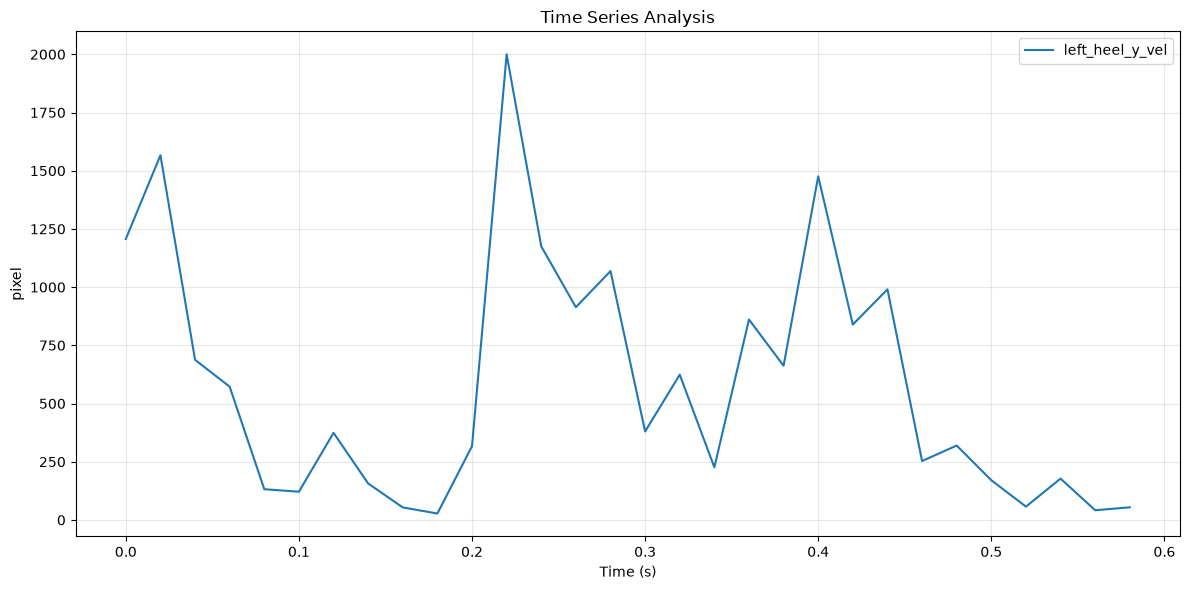

In [111]:
visualize_time(df_test2, 50)

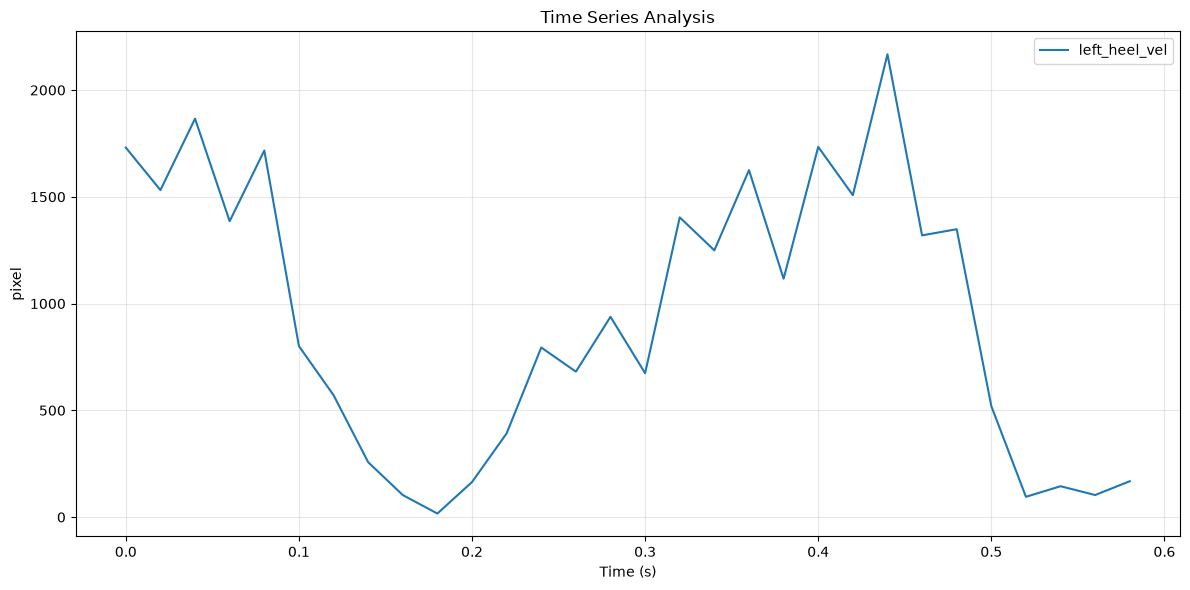

In [112]:
visualize_time(vel_acc_df["left_heel_vel"], 50)

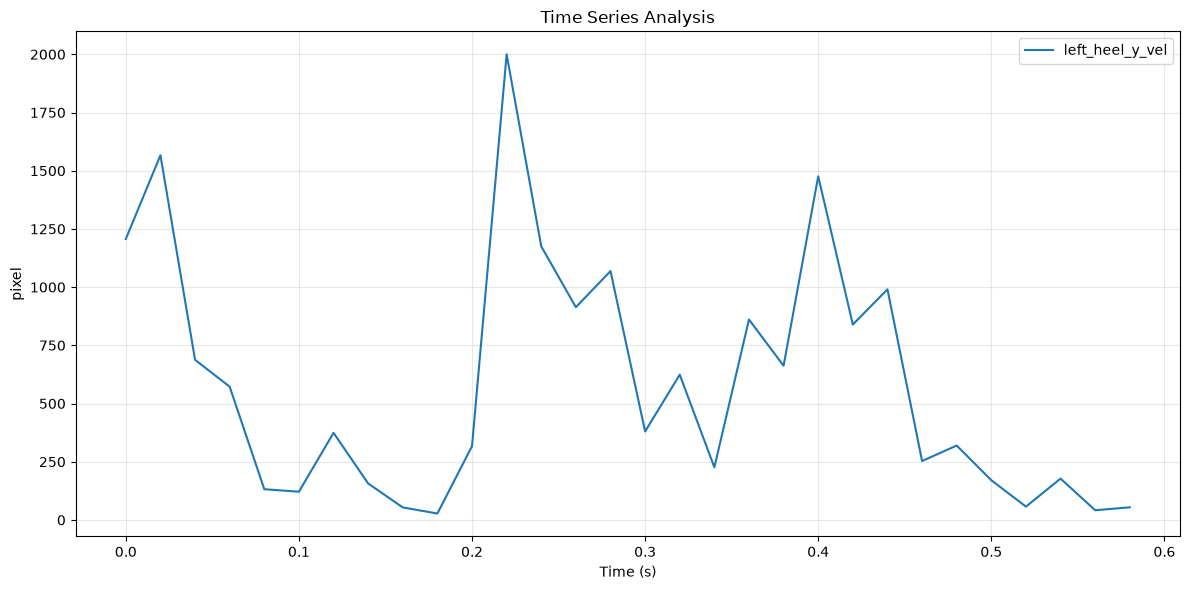

In [113]:
visualize_time(df_test2, 50)

In [114]:
'_'.join("left_heel_x".split('_')[:-1])

'left_heel'

In [115]:
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.plot(df["left_heel_x"], 1080 - df["left_heel_y"])
# fig.tight_layout()
# fig.show()
def visualize_xy(_df: pd.DataFrame, height: int) -> None:
    if type(_df) == pd.Series:
        raise RuntimeError("x, y가 주어져야 합니다.")
    columns = set('_'.join(col.split('_')[:-1]) for col in _df.columns)

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in columns:
        axes.plot(_df[f"{col}_x"], height - _df[f"{col}_y"], label=col, linewidth=1.5)
    axes.set_title("Trace Analysis")
    axes.set_xlabel("x")
    axes.set_ylabel("y")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [116]:
def gct(df, side: str):
    """
    {side}의 heel이 지면에 접촉하고 big_toe가 지면에서 떼어지는 순간까지의 인덱스 출력
    """
    heel = f"{side}_heel"
    start = int(df[f"{heel}_y"].argmax())

    toe = f"{side}_big_toe"
    min_value = df[f"{toe}_y"].max()

    inside = df[f"{toe}_y"].between(min_value - 5, min_value)
    end = df.index[~inside & inside.shift(1, fill_value=False)].to_list()[0]
    return start - 1, end - 1




In [117]:
gct(df, "left")

(26, 4)

In [118]:
gct(df, "right")

(0, 4)

In [119]:
heel = "left_heel"
max_value = df[f"{heel}_y"].argmax()

In [120]:
max_value - 1

np.int64(26)

In [121]:
df[f"{heel}_y"]

0     522.953126
1     528.514211
2     552.648530
3     583.973863
4     597.729244
5     609.174415
6     606.535558
7     608.959883
8     616.441736
9     613.310747
10    612.235060
11    611.685040
12    605.346956
13    593.096612
14    569.596884
15    551.322449
16    529.945741
17    522.342473
18    509.863238
19    505.346087
20    522.560418
21    535.807549
22    565.331471
23    582.116503
24    601.927722
25    606.986933
26    613.377876
27    616.787918
28    615.645092
29    612.094552
30    611.261744
31    610.178259
Name: left_heel_y, dtype: float64

In [122]:
[df[f"{heel}_y"] > max_value - 10]

[0     True
 1     True
 2     True
 3     True
 4     True
 5     True
 6     True
 7     True
 8     True
 9     True
 10    True
 11    True
 12    True
 13    True
 14    True
 15    True
 16    True
 17    True
 18    True
 19    True
 20    True
 21    True
 22    True
 23    True
 24    True
 25    True
 26    True
 27    True
 28    True
 29    True
 30    True
 31    True
 Name: left_heel_y, dtype: bool]

In [123]:
#    13: "left_knee",
#    14: "right_knee",

In [124]:
lkv = vel_acc_df["left_knee_vel"].to_frame()
lka = vel_acc_df["left_knee_acc"].to_frame()


In [125]:
fps = 25

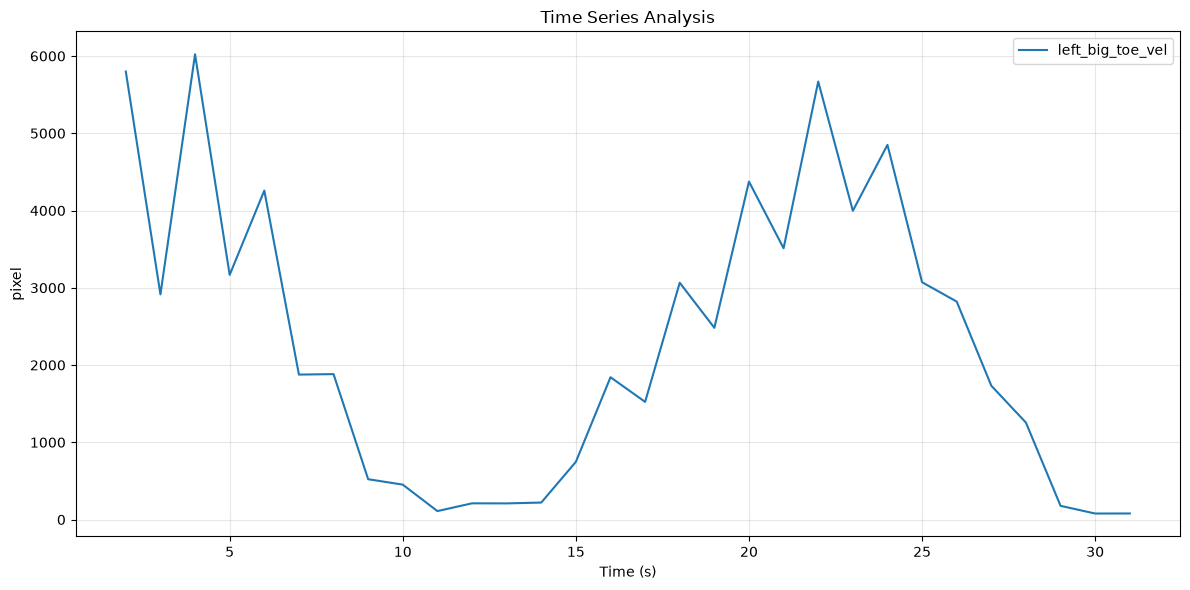

In [126]:
visualize_frame(vel_acc(df, ["left_big_toe"], fps=60)["left_big_toe_vel"])

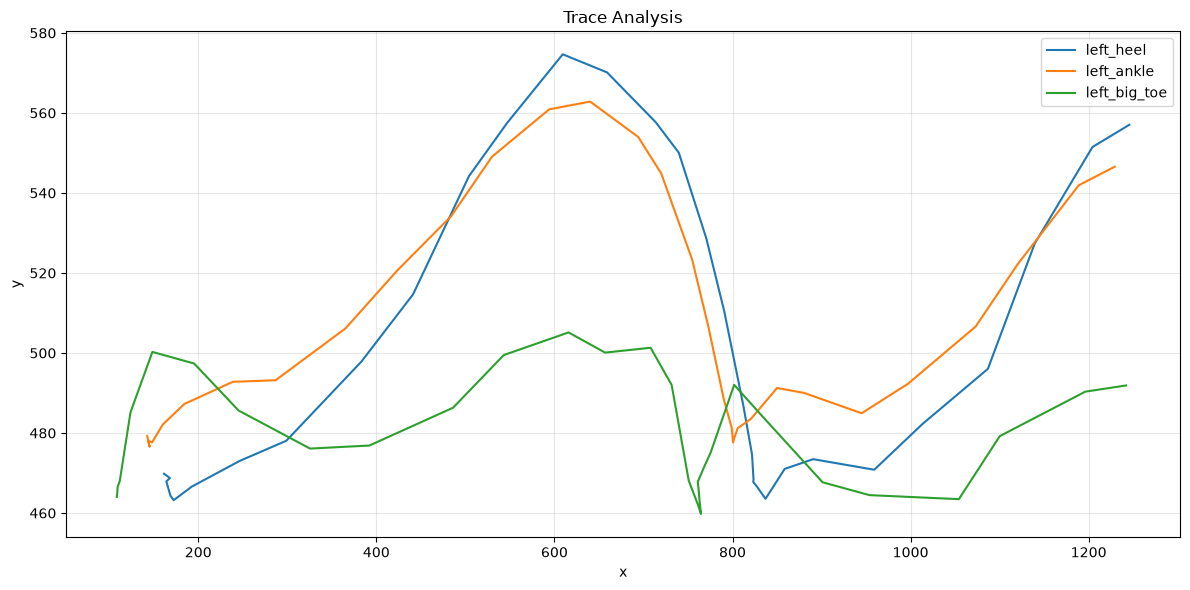

In [127]:
visualize_xy(df[["left_heel_x", "left_heel_y", "left_big_toe_x", "left_big_toe_y", "left_ankle_x", "left_ankle_y"]], 1080)

In [128]:
# def knee_flexion_angle(hip, knee, ankle) -> float:

#     thigh = (np.asarray(hip, dtype=float) - np.asarray(knee, dtype=float)).T

#     shank = (np.asarray(ankle, dtype=float) - np.asarray(knee, dtype=float)).T

#     denominator = np.linalg.norm(thigh, axis=1) * np.linalg.norm(shank, axis=1)

#     # if denominator == 0 or not np.isfinite(denominator):
#     #     return np.nan
#     cosine = np.clip(np.sum((thigh * shank), axis=1) / denominator, -1.0, 1.0)

#     joint_angle = np.clip(np.degrees(np.arccos(cosine)), 0, 180)

#     return 180.0 - joint_angle

In [129]:
def knee_flexion_angle(
    hip,
    knee,
    ankle,
    orientation: float = 1.0,
) -> np.ndarray:
    """
    무릎 굴곡 각도를 계산한다.

    반환값:
        정상 굴곡: 양수
        완전 신전: 0
        반대 방향 과신전: 음수

    orientation:
        촬영 방향 때문에 부호가 반대이면 -1.0을 전달한다.
    """
    thigh = (
        np.asarray(hip, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    shank = (
        np.asarray(ankle, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    thigh_norm = np.linalg.norm(thigh, axis=1)
    shank_norm = np.linalg.norm(shank, axis=1)

    valid = (
        np.isfinite(thigh_norm)
        & np.isfinite(shank_norm)
        & (thigh_norm > 1e-8)
        & (shank_norm > 1e-8)
    )

    result = np.full(len(thigh), np.nan, dtype=float)

    dot = np.sum(thigh[valid] * shank[valid], axis=1)

    cross = (
        thigh[valid, 0] * shank[valid, 1]
        - thigh[valid, 1] * shank[valid, 0]
    )

    # 무릎을 중심으로 한 두 벡터의 방향 포함 각도
    signed_joint_angle = np.degrees(
        np.arctan2(cross, dot)
    )

    direction = np.where(signed_joint_angle >= 0, 1.0, -1.0)

    result[valid] = (
        orientation
        * direction
        * (180.0 - np.abs(signed_joint_angle))
    )

    # 부동소수점으로 생기는 극소값 제거
    result[np.isclose(result, 0.0, atol=1e-8)] = 0.0

    return result

In [130]:
df["left_hip_y"].shape

(32,)

In [131]:
help(np.arctan2)

Help on ufunc in module numpy:

arctan2 = <ufunc 'arctan2'>
    arctan2(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Element-wise arc tangent of ``x1/x2`` choosing the quadrant correctly.

    The quadrant (i.e., branch) is chosen so that ``arctan2(x1, x2)`` is
    the signed angle in radians between the ray ending at the origin and
    passing through the point (1,0), and the ray ending at the origin and
    passing through the point (`x2`, `x1`).  (Note the role reversal: the
    "`y`-coordinate" is the first function parameter, the "`x`-coordinate"
    is the second.)  By IEEE convention, this function is defined for
    `x2` = +/-0 and for either or both of `x1` and `x2` = +/-inf (see
    Notes for specific values).

    This function is not defined for complex-valued arguments; for the
    so-called argument of complex values, use `angle`.

    Parameters
    ----------
    x1 : array_like, real-valued
        `y`-co

In [132]:
df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y', 'right_instep_x', 'right_inst

In [133]:
(df["nose_x"] - df["neck_x"])[0]

np.float64(-34.45008680555543)

In [134]:
left_knee_angle = knee_flexion_angle(
    [df["left_hip_x"], df["left_hip_y"]],
    [df["left_knee_x"], df["left_knee_y"]],
    [df["left_ankle_x"], df["left_ankle_y"]]
)

In [135]:
1 == True

True

In [136]:
발착지예상프레임 = left_knee_angle.argmin() - 1

In [137]:
발착지예상프레임

np.int64(25)

In [138]:
df["left_heel_y"]

0     522.953126
1     528.514211
2     552.648530
3     583.973863
4     597.729244
5     609.174415
6     606.535558
7     608.959883
8     616.441736
9     613.310747
10    612.235060
11    611.685040
12    605.346956
13    593.096612
14    569.596884
15    551.322449
16    529.945741
17    522.342473
18    509.863238
19    505.346087
20    522.560418
21    535.807549
22    565.331471
23    582.116503
24    601.927722
25    606.986933
26    613.377876
27    616.787918
28    615.645092
29    612.094552
30    611.261744
31    610.178259
Name: left_heel_y, dtype: float64

In [139]:
TD = df["left_heel_y"].argmax()

In [140]:
TD

np.int64(27)

In [141]:
left_knee_angle

array([75.86328144, 84.65337946, 77.67527097, 61.09995099, 35.63084158,
       10.12467166,  0.51376255, -2.73492625,  4.54451118, 12.87209168,
       35.69632428, 39.69074458, 30.86197467, 20.86521391, 18.52906359,
       20.99871903, 34.73768679, 50.17552253, 76.79798033, 88.39672024,
       92.98873473, 88.37931716, 71.43917134, 45.88849055, 18.71838018,
        4.28856101, -6.38218223, -4.36708495, 18.5118371 , 30.24526736,
       41.54383904, 40.09680728])

In [142]:
left_knee_angle[12]

np.float64(30.86197466800209)

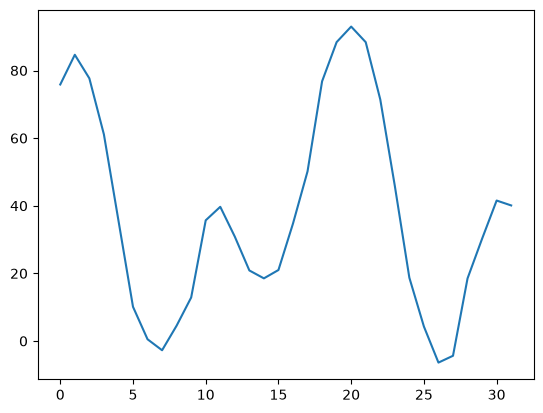

In [143]:
plt.plot(left_knee_angle)

In [144]:
y = np.asarray(left_knee_angle, dtype=float)
x = np.arange(len(y))

In [145]:
y_smooth = savgol_filter(
    y,
    window_length=5,
    polyorder=2
)

In [168]:
len(y)

32

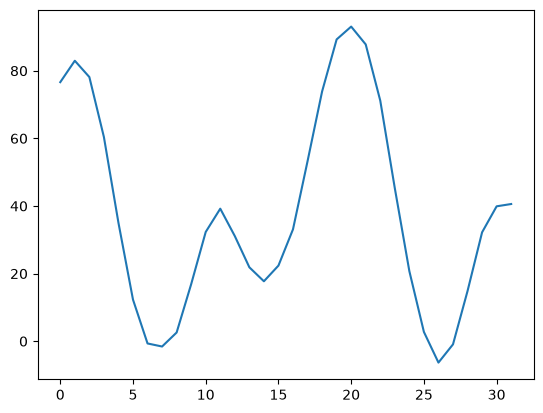

In [146]:
plt.plot(y_smooth)

In [172]:
distance = len(y) // 6

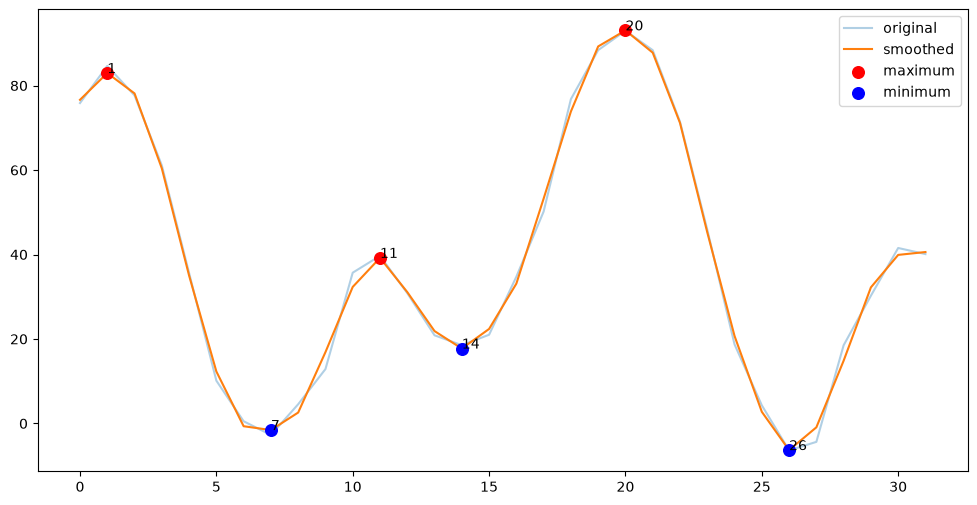

최댓값 프레임: [ 1 11 20]
최솟값 프레임: [ 7 14 26]


In [173]:
# 데이터 범위에 비례해 prominence 설정
signal_range = np.percentile(y_smooth, 95) - np.percentile(y_smooth, 5)
prominence = signal_range * 0.05    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

# 최댓값
max_indices, max_properties = find_peaks(
    y_smooth,
    prominence=prominence,
    distance=distance,
)

# 최솟값: 신호에 -를 붙여서 봉우리로 변환
min_indices, min_properties = find_peaks(
    -y_smooth,
    prominence=prominence,
    distance=distance,
)

plt.figure(figsize=(12, 6))
plt.plot(x, y, alpha=0.35, label="original")
plt.plot(x, y_smooth, label="smoothed")

plt.scatter(
    max_indices,
    y_smooth[max_indices],
    color="red",
    s=70,
    label="maximum",
    zorder=3,
)

plt.scatter(
    min_indices,
    y_smooth[min_indices],
    color="blue",
    s=70,
    label="minimum",
    zorder=3,
)

for i in max_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

for i in min_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

plt.legend()
plt.show()

print("최댓값 프레임:", max_indices)
print("최솟값 프레임:", min_indices)

In [148]:
_max = {
    "frame": max_indices,
    "class": np.ones_like(max_indices)
}
_min = {
    "frame": min_indices,
    "class": np.zeros_like(min_indices)
}
extremum = pd.concat([pd.DataFrame(_max), pd.DataFrame(_min)]).sort_values('frame')


In [149]:
extremum

,frame,class
0,7,0
0,20,1
1,26,0


In [150]:
for i in range(1, len(extremum)):
    previous = extremum["class"].iloc[i - 1]
    current = extremum["class"].iloc[i]

    assert {previous, current} == {0, 1}, (
        f"예외: {i-1}, {i}행의 값이 {previous}, {current}입니다."
    )


In [151]:
res = []
for i in range(len(extremum) // 4 + 1):
    res.append(extremum['frame'].iloc[4 * i : 4 * i + 5].to_list())

In [152]:
res

[[7, 20, 26]]

In [153]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y,right_instep_x,right_instep_y
0,1046.629517,170.064392,1260.546875,630.197754,1069.709663,219.642568,1078.696642,212.153419,1070.458577,210.655589,...,1247.202501,578.372833,1077.947727,616.567496,1245.704671,522.953126,1140.107666,612.822921,1095.547228,611.325091
1,1029.660889,180.629883,1219.755859,633.277344,1043.667976,222.770890,1052.508746,215.403581,1044.404707,214.666850,...,1205.012041,581.558835,1082.714713,616.185187,1204.275311,528.514211,1135.759337,614.711725,1097.817696,612.133167
2,961.070496,179.331512,1153.365601,634.242188,1006.869831,217.240743,1015.014390,208.355769,1006.129416,208.355769,...,1112.749106,600.035060,1084.613355,616.324180,1139.404029,552.648530,1137.923200,610.400864,1097.940816,611.141278
3,951.601257,170.442886,1150.759033,635.608459,980.769373,206.935359,989.854638,199.364305,980.012268,197.850094,...,1070.864916,612.743869,1082.978603,616.529397,1086.764130,583.973863,1129.162032,598.358866,1093.578078,605.929921
4,930.450317,155.854858,1125.763428,631.148315,943.785666,195.462646,953.068741,187.726750,943.012076,186.953161,...,966.219765,615.521805,1078.390258,616.295395,1013.408731,597.729244,1111.654612,574.521556,1086.126154,598.116039
5,887.126282,147.926941,1108.082397,629.719604,918.403426,190.428828,927.029271,182.587150,917.619258,181.018815,...,913.698419,616.231925,1075.236979,609.174415,959.180150,609.174415,1090.920334,555.066839,1072.884476,586.825634
6,832.787415,141.903595,1074.503662,626.407776,881.096051,190.164762,888.981861,182.278951,880.307470,179.913208,...,840.878417,602.592652,1050.640977,591.552518,890.559024,606.535558,1059.315369,534.774682,1047.092363,568.683667
7,795.743774,144.564301,1052.130249,622.334961,855.506321,192.154755,864.060158,185.156162,855.506321,182.823297,...,808.071411,596.517939,1027.360669,580.965509,858.616807,608.959883,1033.581641,518.755788,1023.861372,555.692810
8,770.720825,155.846222,921.823181,628.915222,815.473209,202.968347,823.172900,195.268656,816.243178,192.958749,...,785.444414,611.821921,986.406347,569.473622,837.032344,616.441736,983.326471,500.946376,976.781734,544.449628
9,759.675415,163.036316,891.726440,632.568909,789.018692,213.627220,797.425038,205.220875,790.547119,204.456662,...,779.848133,616.367600,951.031900,568.986379,827.229354,613.310747,942.625554,500.207187,938.422381,545.677875
